In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
vermogen = 100_000

# rendement
dividend_yield = 0.02
growth_rate = 0.05

# belasting
box_3_tarief = 0.36
vpb = 0.19
box_2_tarief = 0.245
vrijstelling = 1800

# kosten
bid_ask_spread = 0.01
oprichtingskosten = 2_000
jaarlijkse_kosten = 1_000

# optimaal
# bid_ask_spread = 0
# oprichtingskosten = 0
# jaarlijkse_kosten = 0

# simulatie
n = 30

In [4]:
def get_market():
    data = pd.DataFrame(columns=["vermogen"])
    data.loc[0, "vermogen"] = vermogen

    for t in range(1, n + 1):
        data.loc[t, "vermogen"] = data.loc[t - 1, "vermogen"] * (
            1 + dividend_yield + growth_rate
        )
    return data

In [5]:
def get_box3():
    data = pd.DataFrame(columns=["vermogen", "bruto", "belasting", "netto"])
    data.loc[0, "vermogen"] = vermogen

    for t in range(1, n + 1):
        data.loc[t, "bruto"] = data.loc[t - 1, "vermogen"] * (
            dividend_yield + growth_rate
        )
        data.loc[t, "belasting"] = max(
            0, data.loc[t, "bruto"] * box_3_tarief - vrijstelling
        )
        data.loc[t, "netto"] = data.loc[t, "bruto"] - data.loc[t, "belasting"]

        data.loc[t, "vermogen"] = data.loc[t - 1, "vermogen"] + data.loc[t, "netto"]
    return data

In [6]:
def get_box2():
    data = pd.DataFrame(
        columns=[
            "vermogen",
            "capital_unrealized",
            "te_verrekenen_verlies",
            "cost_basis",
            "dividend",
            "koerswinst",
            "bruto",
            "belasting",
            "netto",
            "total_profit_before_tax",
            "total_profit_after_tax",
        ]
    )
    
    data.loc[0, "vermogen"] = vermogen
    geinvesteerd_vermogen = data.loc[0, "vermogen"] * (1 - bid_ask_spread)
    data.loc[0, "capital_unrealized"] = geinvesteerd_vermogen - oprichtingskosten
    data.loc[0, "te_verrekenen_verlies"] = oprichtingskosten
    data.loc[0, "cost_basis"] = data.loc[0, "capital_unrealized"]

    assert (
        data.loc[0, "capital_unrealized"] * (dividend_yield + growth_rate)
        > jaarlijkse_kosten
    ), "Rendement eerste jaar moet jaarlijkse kosten dekken."

    for t in range(1, n + 1):
        data.loc[t, "dividend"] = data.loc[t - 1, "capital_unrealized"] * dividend_yield
        data.loc[t, "koerswinst"] = data.loc[t - 1, "capital_unrealized"] * growth_rate
        data.loc[t, "bruto"] = data.loc[t, "dividend"] - jaarlijkse_kosten
        data.loc[t, "te_verrekenen_verlies"] = data.loc[t - 1, "te_verrekenen_verlies"]
        if data.loc[t, "bruto"] < 0:
            # verkoop aandelen die in waarde zijn gestegen om kosten te dekken
            data.loc[t, "koerswinst"] = data.loc[t, "koerswinst"] - data.loc[t, "bruto"]
            data.loc[t, "te_verrekenen_verlies"] = (
                data.loc[t, "te_verrekenen_verlies"] + data.loc[t, "bruto"]
            )
            data.loc[t, "bruto"] = 0
            assert data.loc[t, "koerswinst"] > 0, "Zou nooit minder dan nul moeten zijn"

        # Bepaal hoeveel belasting moet worden betaald.
        # Alleen als er winst is en geen verlies meer te verrekenen is.
        data.loc[t, "belasting"] = 0
        if data.loc[t, "te_verrekenen_verlies"] > data.loc[t, "bruto"]:
            data.loc[t, "te_verrekenen_verlies"] = (
                data.loc[t, "te_verrekenen_verlies"] - data.loc[t, "bruto"]
            )
        else:
            data.loc[t, "belasting"] = (
                data.loc[t, "bruto"] - data.loc[t, "te_verrekenen_verlies"]
            ) * vpb
            data.loc[t, "te_verrekenen_verlies"] = 0

        data.loc[t, "netto"] = data.loc[t, "bruto"] - data.loc[t, "belasting"]

        # Update nieuwe ongerealiseerde prive_vermogen. Investeer netto winst en tel koerswinst op.
        data.loc[t, "capital_unrealized"] = (
            data.loc[t - 1, "capital_unrealized"]
            + data.loc[t, "netto"]
            + data.loc[t, "koerswinst"]
        )
        data.loc[t, "cost_basis"] = data.loc[t - 1, "cost_basis"] + data.loc[t, "netto"]

        # Converteer prive_vermogen naar prive.
        # Stap 1: Alle koerswinst wordt gerealiseerd.
        # Indien meer dan nog te verrekenen verliezen, betaal vpb.
        data.loc[t, "total_profit_before_tax"] = (
            data.loc[t, "capital_unrealized"] - data.loc[t, "cost_basis"]
        )
        if (
            data.loc[t, "te_verrekenen_verlies"]
            < data.loc[t, "total_profit_before_tax"]
        ):
            data.loc[t, "tax"] = (
                data.loc[t, "total_profit_before_tax"]
                - data.loc[t, "te_verrekenen_verlies"]
            ) * vpb
        else:
            data.loc[t, "tax"] = 0
        data.loc[t, "total_profit_after_tax"] = (
            data.loc[t, "total_profit_before_tax"] - data.loc[t, "tax"]
        )

        # Stap 2: Uitkering vermogen BV naar prive.
        # Afrekenen dividend belasting indien meer vermogen dan geinvesteerd vermogen.
        if (
            data.loc[t, "total_profit_after_tax"] + data.loc[t, "cost_basis"]
        ) < geinvesteerd_vermogen:
            data.loc[t, "vermogen"] = (
                data.loc[t, "total_profit_after_tax"] + data.loc[t, "cost_basis"]
            )
        else:
            data.loc[t, "vermogen"] = geinvesteerd_vermogen + (
                data.loc[t, "total_profit_after_tax"]
                + data.loc[t, "cost_basis"]
                - geinvesteerd_vermogen
            ) * (1 - box_2_tarief)
    return data

In [7]:
def get_box2_optimaal():
    """What if:
    - Geen verlies door liquideren en aankopen.
    - Geen oprichtingskosten.
    - Geen jaarlijkse kosten.
    - Wel jaarlijks vpb over dividend.
    - Bij opheffen:
        - vpb over ongerealiseerde koerswinst (niet over betaalde dividend yield)
        - box 2 belasting over totale BV winst"""
    data = pd.DataFrame(columns=["vermogen"])
    data.loc[0, "vermogen"] = vermogen
    total = vermogen
    taxed_already = 0
    for t in range(1, n + 1):
        taxed_already = taxed_already + total * dividend_yield * (1 - vpb)
        total = total * (1 + growth_rate + dividend_yield * (1 - vpb))
        after_tax = (total - vermogen - taxed_already) * (1 - vpb)
        data.loc[t, "vermogen"] = vermogen + (taxed_already + after_tax) * (
            1 - box_2_tarief
        )
    return data


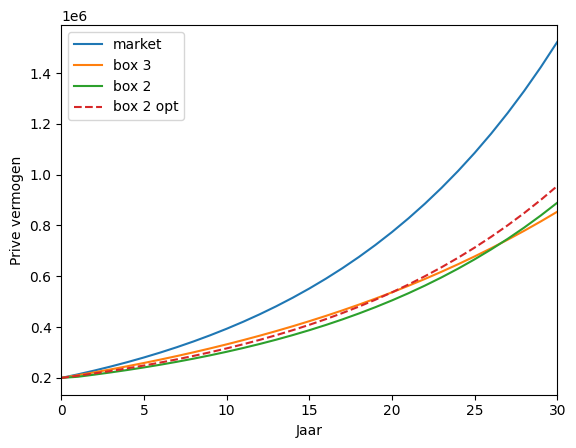

In [8]:
vermogen = 200_000
market = get_market()
box3 = get_box3()
box2 = get_box2()
opt = get_box2_optimaal()
plt.plot(market["vermogen"], label="market")
plt.plot(box3["vermogen"], label="box 3")
plt.plot(box2["vermogen"], label="box 2")
plt.plot(opt["vermogen"], label="box 2 opt", linestyle='--')

plt.ylabel("Prive vermogen")
plt.xlabel("Jaar")
plt.xlim([0, n])
plt.legend()
plt.show()

In [9]:
# %%time
# for _ in range(10):
#     vermogen = 100000
#     box2 = get_box2()

In [10]:
# import matplotlib.colors as mcolors
# mcolors.TABLEAU_COLORS

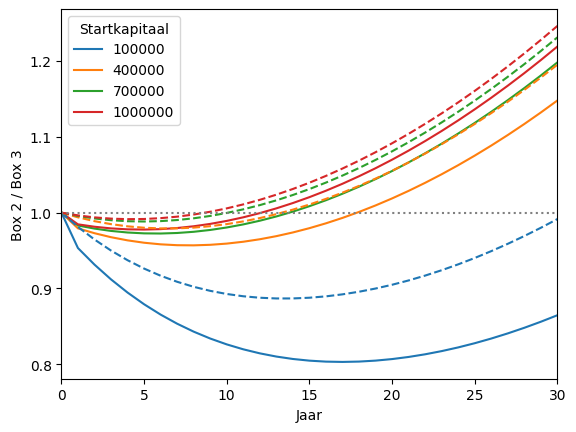

In [11]:
colors = {
    "tab:blue": "#1f77b4",
    "tab:orange": "#ff7f0e",
    "tab:green": "#2ca02c",
    "tab:red": "#d62728",
    "tab:purple": "#9467bd",
    "tab:brown": "#8c564b",
    "tab:pink": "#e377c2",
    "tab:gray": "#7f7f7f",
    "tab:olive": "#bcbd22",
    "tab:cyan": "#17becf",
}

for optimaal in [False, True]:
    for color, vermogen in zip(colors, np.linspace(100_000, 1_000_000, 4)):
        box3 = get_box3()

        if optimaal:
            box2 = get_box2_optimaal()

            relatief = box2.vermogen / box3.vermogen
            plt.plot(relatief, linestyle="--", c=color)
        else:
            box2 = get_box2()

            relatief = box2.vermogen / box3.vermogen
            plt.plot(relatief, label=f"{vermogen:.0f}", linestyle="-", c=color)

plt.ylabel("Box 2 / Box 3")
plt.xlabel("Jaar")
plt.axhline(1.0, color="grey", linestyle=":")
plt.xlim([0, n])
plt.legend(title="Startkapitaal")
plt.show()

In [12]:
# box2 = get_box2()
# box2

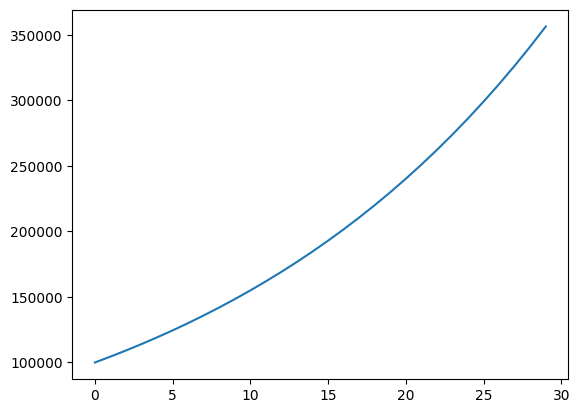

In [13]:
vermogen_start = 100_000
prijs_groei = 0.05
dividend_yield = 0.02
import numpy as np
t = np.arange(0, 30)

vermogen_t = vermogen_start * (1 + (prijs_groei + dividend_yield) * (1 - 0.36)) ** t
plt.plot(vermogen_t)

In [14]:
# with vectors

a = np.array([[1,2,3],[5,2,3]])
max_vermogen = np.array([[2,3,4]])

In [15]:

a = np.array([[1,2,3],[5,2,3]])

In [16]:
np.max(a, axis=0)

array([5, 2, 3])

In [17]:
np.maximum(a[-1], max_vermogen)

array([[5, 3, 4]])

In [18]:
a[-1]

array([5, 2, 3])

In [19]:
vermogen = 100_000

n = 100
t = 30
r = np.random.normal(0.07, 0.01, (n, t))
v = np.zeros((n, t))
v[0, :] = vermogen
max_vermogen = np.maximum(0, v[0, :])
v[1, :] = vermogen * (1 + r[1, :])

In [20]:
profit = v[1, :] - max_vermogen
belasting = np.maximum(0, profit * 0.36 - 1800)
profit, belasting
v[1, :] -= belasting

max_vermogen = np.maximum(v[0, :], v[1, :])

In [21]:
vermogen = 100_000
n = 10_000
t = 30
r = np.random.normal(0.07, 0.1, (t + 1, n))
dividend_yield = 0.02
v = np.zeros((t + 1, n))
v[0, :] = vermogen
for tt in range(1, t + 1):
    max_vermogen = np.max(v, axis=0)
    v[tt, :] = v[tt - 1, :] * (1 + r[tt, :])
    bruto = v[tt, :] - max_vermogen
    belasting = np.maximum(0, bruto * 0.36 - 1800)
    v[tt, :] -= belasting

In [22]:
# plt.plot(v)
# plt.show()

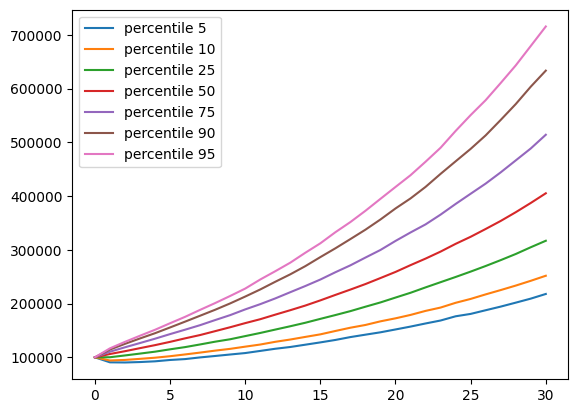

In [23]:
for q in [5, 10, 25, 50, 75, 90, 95]:
    plt.plot(np.percentile(v, q=q, axis=1), label=f"percentile {q}")
plt.legend()
plt.show()

In [24]:
v[:10]

array([[100000.        , 100000.        , 100000.        , ...,
        100000.        , 100000.        , 100000.        ],
       [112695.32375429, 110089.03672237,  86273.21586158, ...,
        109416.65302852, 105385.68474255, 106280.24726439],
       [121538.15577907, 122343.19200486,  84191.98242264, ...,
        114543.79012126, 129215.72175115,  99818.92417762],
       ...,
       [120711.81189686, 193925.88699225, 101438.09857229, ...,
        115176.42121381, 166985.87184293, 135146.75538974],
       [132374.50821098, 218002.48624932,  96565.86472392, ...,
        128294.80883878, 173863.33342483, 135145.96644923],
       [126374.20009083, 235914.59348553, 102191.98159344, ...,
        110116.56587252, 173068.8782781 , 144527.47168838]],
      shape=(10, 10000))

In [25]:
106280/100000, 7000*0.36-1800

(1.0628, 720.0)

In [26]:
# vermogen = 100_000
# n = 10
# t = 3
# dividend_yield = 0.02
# r = np.random.normal(0.07, 0.2, (t + 1, n)) - dividend_yield

r -= dividend_yield

v2 = np.zeros((t + 1, n))
v2[0, :] = vermogen

total = np.ones(n) * vermogen
taxed_already = np.zeros(n)
for tt in range(1, t + 1):
    taxed_already = taxed_already + total * dividend_yield * (1 - vpb)
    total = total * (1 + r[tt, :] + dividend_yield * (1 - vpb))
    after_tax = (total - vermogen - taxed_already) * (1 - vpb)
    v2[tt, :] = vermogen + (taxed_already + after_tax) * (1 - box_2_tarief)

In [27]:
r

array([[ 0.09794738,  0.01868624,  0.10601077, ..., -0.04508473,
         0.01745755,  0.05247187],
       [ 0.15023943,  0.1095162 , -0.15726784, ...,  0.0990102 ,
         0.03602632,  0.05000386],
       [ 0.07764757,  0.12837642, -0.04412375, ...,  0.02751244,
         0.30662817, -0.08079515],
       ...,
       [ 0.02236547,  0.10361671,  0.09334159, ..., -0.08880304,
        -0.09386565, -0.12675807],
       [ 0.02385048, -0.01145723,  0.18501844, ...,  0.13114929,
         0.16237834,  0.03401266],
       [ 0.19117538,  0.06519235, -0.09203319, ...,  0.07842519,
        -0.08238732,  0.0225136 ]], shape=(31, 10000))

In [28]:
v.shape, v2.shape

((31, 10000), (31, 10000))

In [29]:
vrel = v2/v

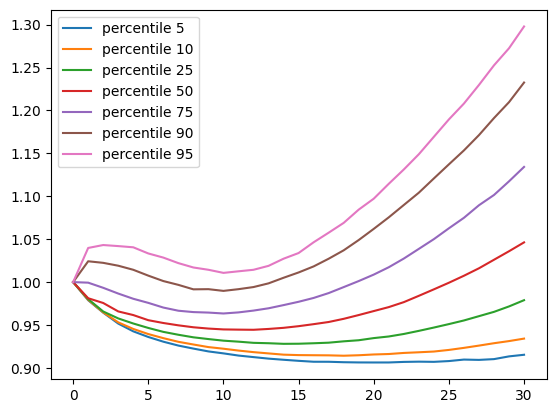

In [30]:
for q in [5, 10, 25, 50, 75, 90, 95]:
    plt.plot(np.percentile(vrel, q=q, axis=1), label=f"percentile {q}")
plt.legend()
plt.show()

<Axes: >

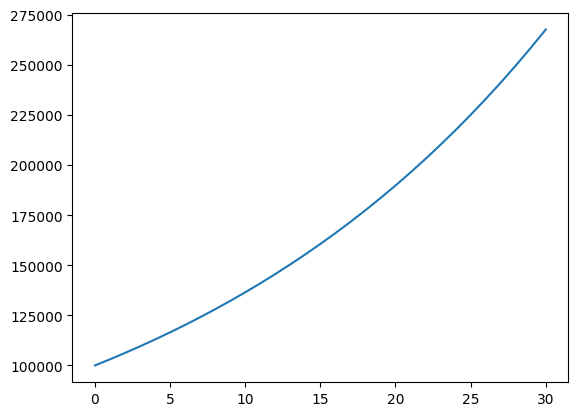

In [52]:
n = 30
vermogen = 100_000
growth_rate = -0.01
dividend_yield = 0.06
box2 = get_box2_optimaal()
box2.vermogen.plot()

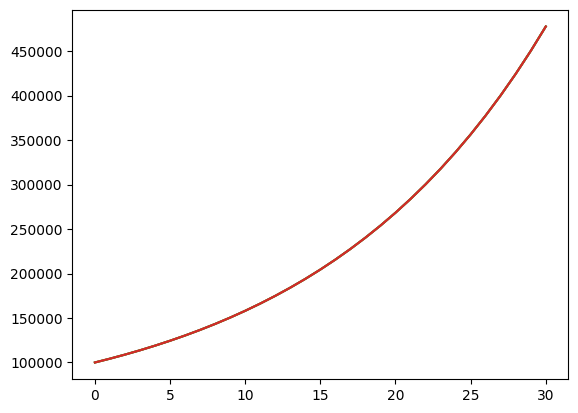

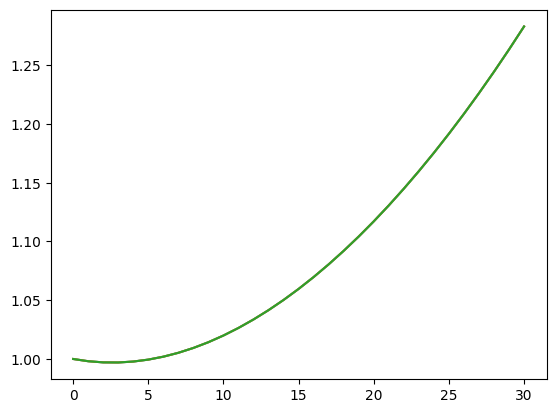

In [59]:
d = 0.02
g = 0.05

t = np.arange(30 + 1)
total = vermogen * (1 + d * (1 - vpb) + g) ** t

taxed_already = (
    vermogen * d * (1 - vpb) * ((d * (1 - vpb) + g + 1) ** t - 1) / (d * (1 - vpb) + g)
)


after_tax = (total - vermogen - taxed_already) * (1 - vpb)
prive = vermogen + (taxed_already + after_tax) * (1 - box_2_tarief)

after2 = (
    vermogen
    * ((1 + d * (1 - vpb) + g) ** t - 1)
    * (g / (d * (1 - vpb) + g))
    * (1 - vpb)
)

b = box_2_tarief
v = vpb
prive2 = vermogen * (
    1
    + (1 - b)
    * (
        ((1 + d * (1 - v) + g) ** t - 1) * (g / (d * (1 - v) + g)) * (1 - v)
        + (d * (1 - v) * ((d * (1 - v) + g + 1) ** t - 1)) / (d * (1 - v) + g)
    )
)


prive3 = vermogen * (
    ((b - 1) * (v - 1) * (d + g) * ((d * (-v) + d + g + 1) ** t - 1))
    / (d * (-v) + d + g)
    + 1
)

growth_rate = g
dividend_yield = d
box2 = get_box2_optimaal()
box2.vermogen.plot()
plt.plot(t, prive)
plt.plot(t, prive2)
plt.plot(t, prive3)
plt.show()

a = 0.36
priveprive = vermogen * (1 + (d + g) * (1 - a)) ** t

ratio = (
    ((b - 1) * (v - 1) * (d + g) * ((d * (-v) + d + g + 1) ** t - 1))
    / (d * (-v) + d + g)
    + 1
) / (1 + (d + g) * (1 - a)) ** t

ratio2 = (
    ((1 - b) * (1 - v) * (d + g) * ((d * (1 - v) + g + 1) ** t - 1)) / (d * (1 - v) + g)
    + 1
) / (1 + (d + g) * (1 - a)) ** t

plt.plot(t, ratio)
plt.plot(t, ratio2)
plt.plot(t, prive / priveprive)


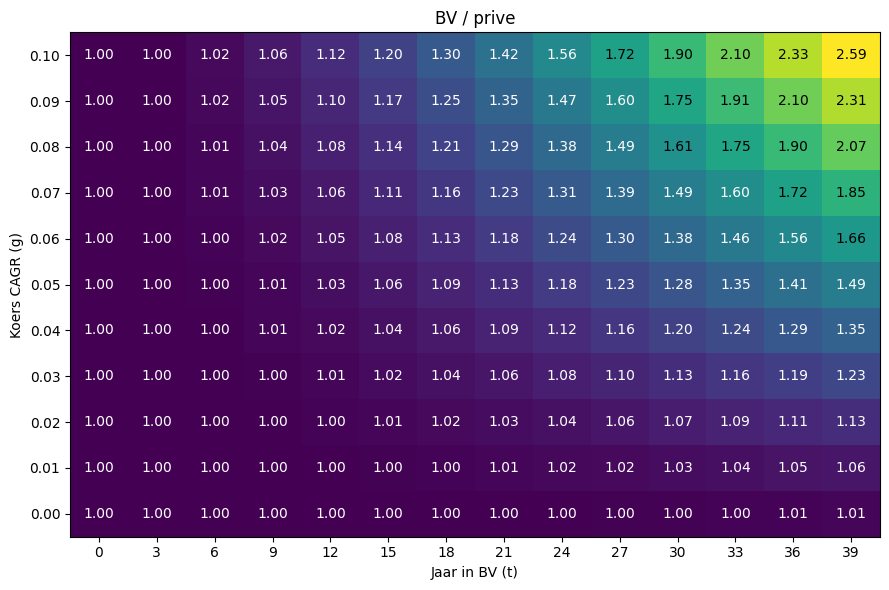

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

ts = np.arange(0, 41, 3)
gs = np.linspace(0, 0.1, 11)

b = 0.245
a = 0.36
v = 0.19
d = 0.02

T, G = np.meshgrid(ts, gs)

ratio = (
    ((b - 1) * (v - 1) * (d + G) * ((d * (-v) + d + G + 1) ** T - 1))
    / (d * (-v) + d + G)
    + 1
) / (1 + (d + G) * (1 - a)) ** T


fig, ax = plt.subplots(figsize=(9, 6))

norm = LogNorm(vmin=ratio.min(), vmax=ratio.max())

im = ax.imshow(
    ratio,
    cmap="viridis",
    norm=norm,
    origin="lower",
    aspect="auto",
)

ax.set_xticks(np.arange(len(ts)))
ax.set_xticklabels(ts)
ax.set_yticks(np.arange(len(gs)))
ax.set_yticklabels([f"{g:.2f}" for g in gs])

ax.set_xlabel("Jaar in BV (t)")
ax.set_ylabel("Koers CAGR (g)")
ax.set_title("BV / prive")

# annotate cells
for i in range(len(gs)):
    for j in range(len(ts)):
        value = ratio[i, j]

        # choose text color based on brightness
        color = "white" if norm(value) < 0.5 else "black"

        ax.text(
            j, i, f"{value:.2f}", ha="center", va="center", color=color, fontsize=10
        )

plt.tight_layout()
plt.show()